<a href="https://colab.research.google.com/github/kushalhole/Data_science_lab_SE_20/blob/main/ds_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 2: Exploratory Data Analysis (EDA)

In this step, we'll delve into the characteristics of our `ratings_df` and `movies_df` DataFrames. Understanding the data is crucial before we proceed with any preprocessing or model building.

### 2.1 Inspecting Basic Information and Missing Values

Let's check the shape, column types, and look for any missing values in both DataFrames. This helps us understand the completeness and structure of our data.

In [1]:
print("\nRatings DataFrame Info:")
ratings_df.info()
print("\nRatings DataFrame Missing Values:")
print(ratings_df.isnull().sum())

print("\nMovies DataFrame Info:")
movies_df.info()
print("\nMovies DataFrame Missing Values:")
print(movies_df.isnull().sum())


Ratings DataFrame Info:


NameError: name 'ratings_df' is not defined

### 2.2 Analyzing Rating Distributions

Understanding how ratings are distributed can give insights into user behavior and potential biases. Let's visualize the distribution of ratings in `ratings_df`.

/tmp/ipykernel_27518/2013896648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


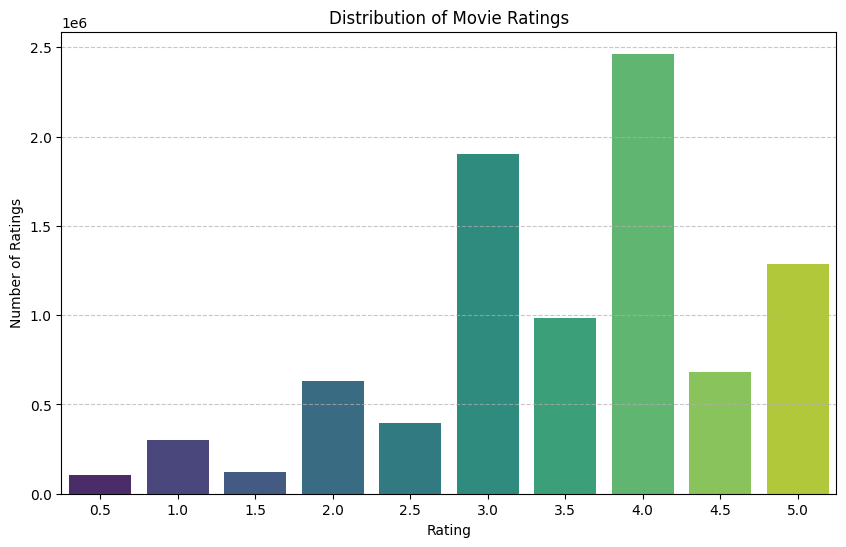

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.3 Exploring Movie Genres

Let's also look at the genres in the `movies_df` to understand the types of movies present in our dataset.

/tmp/ipykernel_27518/2496715379.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=genres_series, order=genres_series.value_counts().index, palette='magma')


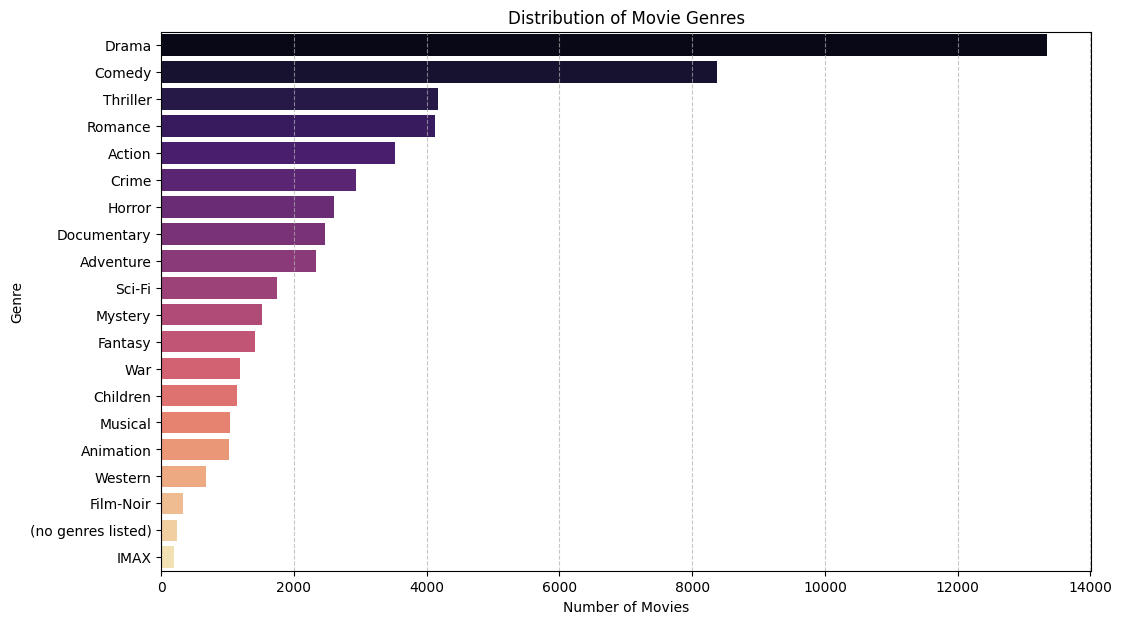

In [ ]:
import numpy as np

# Split genres and count occurrences
genres_flat = [genre for sublist in movies_df['genres'].str.split('|') for genre in sublist]
genres_series = pd.Series(genres_flat)

plt.figure(figsize=(12, 7))
sns.countplot(y=genres_series, order=genres_series.value_counts().index, palette='magma')
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Merge datasets
df = pd.merge(ratings_df, movies_df, on='movieId')

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
genre = "Action"

genre_df = df[df['genres'].str.contains(genre)]

genre_df.head()

,userId,movieId,rating,timestamp,title,genres
5,1,112,3.5,2004-09-10 03:09:00,Rumble in the Bronx (Hont faan kui) (1995),Action|Adventure|Comedy|Crime
6,1,151,4.0,2004-09-10 03:08:54,Rob Roy (1995),Action|Drama|Romance|War
9,1,260,4.0,2005-04-02 23:33:46,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
10,1,293,4.0,2005-04-02 23:31:43,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller
14,1,367,3.5,2005-04-02 23:53:00,"Mask, The (1994)",Action|Comedy|Crime|Fantasy


In [ ]:
avg_rating = genre_df['rating'].mean()
print(f"Average rating for {genre} movies:", avg_rating)

Average rating for Action movies: 3.4442648774094247


In [ ]:
# Take a smaller sample for faster processing
df_sample = df.sample(10000, random_state=42)

# Ensure genres column is clean
df_sample['genres'] = df_sample['genres'].fillna('').astype(str)

# Create dummy variables
genres_dummies = df_sample['genres'].str.get_dummies(sep='|')

# Combine with ratings
model_df = pd.concat([df_sample[['rating']], genres_dummies], axis=1)

model_df.head()

,rating,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
6057092,4.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5975599,4.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5607921,3.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3250586,2.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
651581,2.5,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = model_df.drop('rating', axis=1)
y = model_df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Create input for prediction
input_data = pd.DataFrame([{
    col: 1 if col == "Action" else 0 for col in X.columns
}])

predicted_rating = model.predict(input_data)

print("Predicted Rating for Action movie:", predicted_rating[0])

Predicted Rating for Action movie: 3.4357058809274514


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 1.1031751843642001


In [ ]:
# Convert rating into classes (0 = Bad, 1 = Good)
model_df['rating_class'] = model_df['rating'].apply(lambda x: 1 if x >= 3 else 0)

In [ ]:
X = model_df.drop(['rating', 'rating_class'], axis=1)
y = model_df['rating_class']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[   0  336]
 [   0 1664]]


In [ ]:
input_data = pd.DataFrame([{
    col: 1 if col == "Action" else 0 for col in X.columns
}])

prediction = clf.predict(input_data)

print("Prediction (1=Good, 0=Bad):", prediction[0])

Prediction (1=Good, 0=Bad): 1


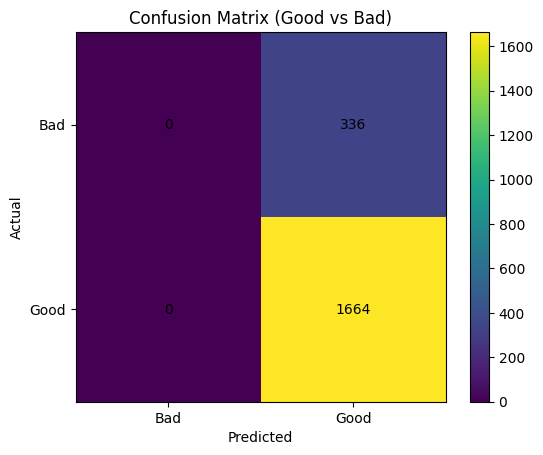

In [ ]:
import matplotlib.pyplot as plt

# Plot confusion matrix
plt.imshow(cm)

plt.title("Confusion Matrix (Good vs Bad)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Label axes
labels = ["Bad", "Good"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

# Show numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.colorbar()
plt.show()